# Notebook 9 - Diurnal Cycles of Clouds

This notebook will dive deeper into cloud frequency over topography throughout the day.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
from typing import Union, Optional, Sequence
import os


import warnings
warnings.filterwarnings("ignore")


/home/cdalden/miniforge3/envs/goes_env/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
def hourly_cloud_freq_simple(ds: xr.Dataset, out_path: str,
                             lon_min: float = -109, lon_max: float = -104,
                             lat_min: float = 37, lat_max: float = 41,
                             hours=range(14,24), time_coord='t',
                             overwrite: bool = False) -> xr.Dataset:
    """
    Compute hourly (per-hour-of-day) mean over month for given hours and save to NetCDF.
    Inputs:
      - ds: xarray.Dataset (already opened)
      - out_path: output netcdf path
      - lon/lat: spatial subset bounds
      - hours: iterable of hours to include (default 14..23)
      - time_coord: name of time coordinate
      - overwrite: replace existing file when True
    Returns:
      - ds_hourly: Dataset with coordinate 'local_hour' and per-hour means
    """
    # Spatial subset
    ds_sub = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

    # ensure datetime-like time
    ds_sub[time_coord] = pd.to_datetime(ds_sub[time_coord].values)

    # select only requested hours
    hour_vals = ds_sub[time_coord].dt.hour
    mask = hour_vals.isin(list(hours))
    if mask.sum() == 0:
        raise RuntimeError("No timesteps found in requested hour range")

    ds_sel = ds_sub.sel({time_coord: ds_sub[time_coord].values[mask.values]})

    # annotate hour coordinate and groupby hour
    ds_sel = ds_sel.assign_coords(hour=(time_coord, ds_sel[time_coord].dt.hour.values))
    ds_hourly = ds_sel.groupby('hour').mean(dim=time_coord)
    ds_hourly = ds_hourly.rename({'hour': 'local_hour'})

    # save
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    if os.path.exists(out_path) and not overwrite:
        raise FileExistsError(f"{out_path} exists (set overwrite=True to replace)")

    encoding = {v: {'zlib': True, 'complevel': 4} for v in ds_hourly.data_vars}
    ds_hourly.to_netcdf(out_path, encoding=encoding)

    return ds_hourly

In [3]:

# for dates in ['202207', '202208', '202301', '202302', '202304', '202305']:
#     month_path = f'/storage/cdalden/goes/colorado/goes16/cloud_counts/goes16_cloud_frequency_colorado_{dates}.nc'
#     month_ds = xr.open_dataset(month_path)
#     out_file = f'/storage/cdalden/goes/colorado/goes16/cloud_counts/goes16_hourly_cloudfreq_{dates}.nc'

#     ds_hourly = hourly_cloud_freq_simple(month_ds, out_file, overwrite=True)
#     month_ds.close()
#     ds_hourly.close()
#     print(f"Processed {dates}")

In [4]:
# May monthly cloud cover
path = '/storage/cdalden/goes/colorado/goes16/cloud_counts/'
file = 'goes16_hourly_cloudfreq_202205.nc'
may22_cloud_ds = xr.open_dataset(path + file)
# subset for faster processing
# lon_min, lon_max = -107.75, -105.75
# lat_min, lat_max = 38, 40
lon_min, lon_max = -109, -104
lat_min, lat_max = 37, 41
may22_cloud_ds = may22_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# May 2023 cloud cover
file = 'goes16_hourly_cloudfreq_202305.nc'
may23_cloud_ds = xr.open_dataset(path + file)
may23_cloud_ds = may23_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# May 2023 cloud cover
file = 'goes16_hourly_cloudfreq_202304.nc'
april23_cloud_ds = xr.open_dataset(path + file)
april23_cloud_ds = april23_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# July cloud cover
file = 'goes16_hourly_cloudfreq_202207.nc'
july_cloud_ds = xr.open_dataset(path + file)
july_cloud_ds = july_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# August cloud cover
file = 'goes16_hourly_cloudfreq_202208.nc'
august_cloud_ds = xr.open_dataset(path + file)
august_cloud_ds = august_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# January cloud cover
file = 'goes16_hourly_cloudfreq_202301.nc'
january_cloud_ds = xr.open_dataset(path + file)
january_cloud_ds = january_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# February cloud cover
file = 'goes16_hourly_cloudfreq_202302.nc'
february_cloud_ds = xr.open_dataset(path + file)
february_cloud_ds = february_cloud_ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

In [5]:
# Path to the DEM file
dem_path = "colorado_dem.tif"

# Open the DEM file
with rasterio.open(dem_path) as src:
    elevation = src.read(1)  # Read the first band (elevation data)
    bounds = src.bounds      # Get the bounds of the DEM
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# for plotting dem
# Generate terrain shading
ls = LightSource(azdeg=315, altdeg=45)  # Azimuth and altitude of the light source
shaded = ls.shade(elevation, cmap=cm.get_cmap("Greys"), vert_exag=1, blend_mode="overlay")



In [6]:
def plot_features(ax, label_color, east_river_labels=False):
    '''
    Add random objects to maps to better understand geography

    ax: axis to plot on (axes obj, 'ax1)
    label_color: specify label color depending on how dark the plot is (str, 'white')
    '''

    

    # Add gridlines with latitude and longitude labels
    gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gridlines.top_labels = False  # Disable top labels
    gridlines.right_labels = False  # Disable right labels
    gridlines.xlabel_style = {'size': 10, 'color': 'black'}
    gridlines.ylabel_style = {'size': 10, 'color': 'black'}

    if east_river_labels:
        ax.set_extent([-107.5, -106.5, 38.4, 39.4], crs=ccrs.PlateCarree())  # east riverish extent
        # Add East River labels
        # Add towns
        ax.plot(-106.9886, 38.958, color=label_color, marker='o', label='Gothic')
        ax.text(-106.9736, 38.958, 'Gothic', fontsize=10, ha='left', color=label_color)

        ax.plot(-106.984, 38.87, color=label_color, marker='o', label='CB')
        ax.text(-106.969, 38.87, 'CB', fontsize=10, ha='left', color=label_color)

        ax.plot(-106.926, 38.545, color=label_color, marker='o', label='Gunnison')
        ax.text(-106.931, 38.565, 'Gunnison', fontsize=10, ha='left', color=label_color)

        ax.plot(-106.822, 39.19, color=label_color, marker='o', label='Aspen')
        ax.text(-106.807, 39.19, 'Aspen', fontsize=10, ha='left', color=label_color)

        # Add peaks
        ax.plot(-107.199, 38.718, color=label_color, marker='^', label='West Elk')
        ax.text(-107.184, 38.718, 'West Elk', fontsize=10, ha='left', color=label_color)

        ax.plot(-106.989, 39.071, color=label_color, marker='^', label='Maroon Pk')
        ax.text(-106.974, 39.071, 'Maroon Pk', fontsize=10, ha='left', color=label_color)

        ax.plot(-107.281, 39.037, color=label_color, marker='^', label='Ragged Pk')
        ax.text(-107.266, 39.037, 'Ragged Pk', fontsize=10, ha='left', color=label_color)

        ax.plot(-107.383, 38.812, color=label_color, marker='^', label='Mt. Gunnison')
        ax.text(-107.368, 38.812, 'Mt. Gunnison', fontsize=10, ha='left', color=label_color)

    roads = cfeature.NaturalEarthFeature(category='cultural', name='roads', scale='10m', facecolor='none')
    ax.add_feature(roads, edgecolor='black', linewidth=0.5)

    # ax.legend()

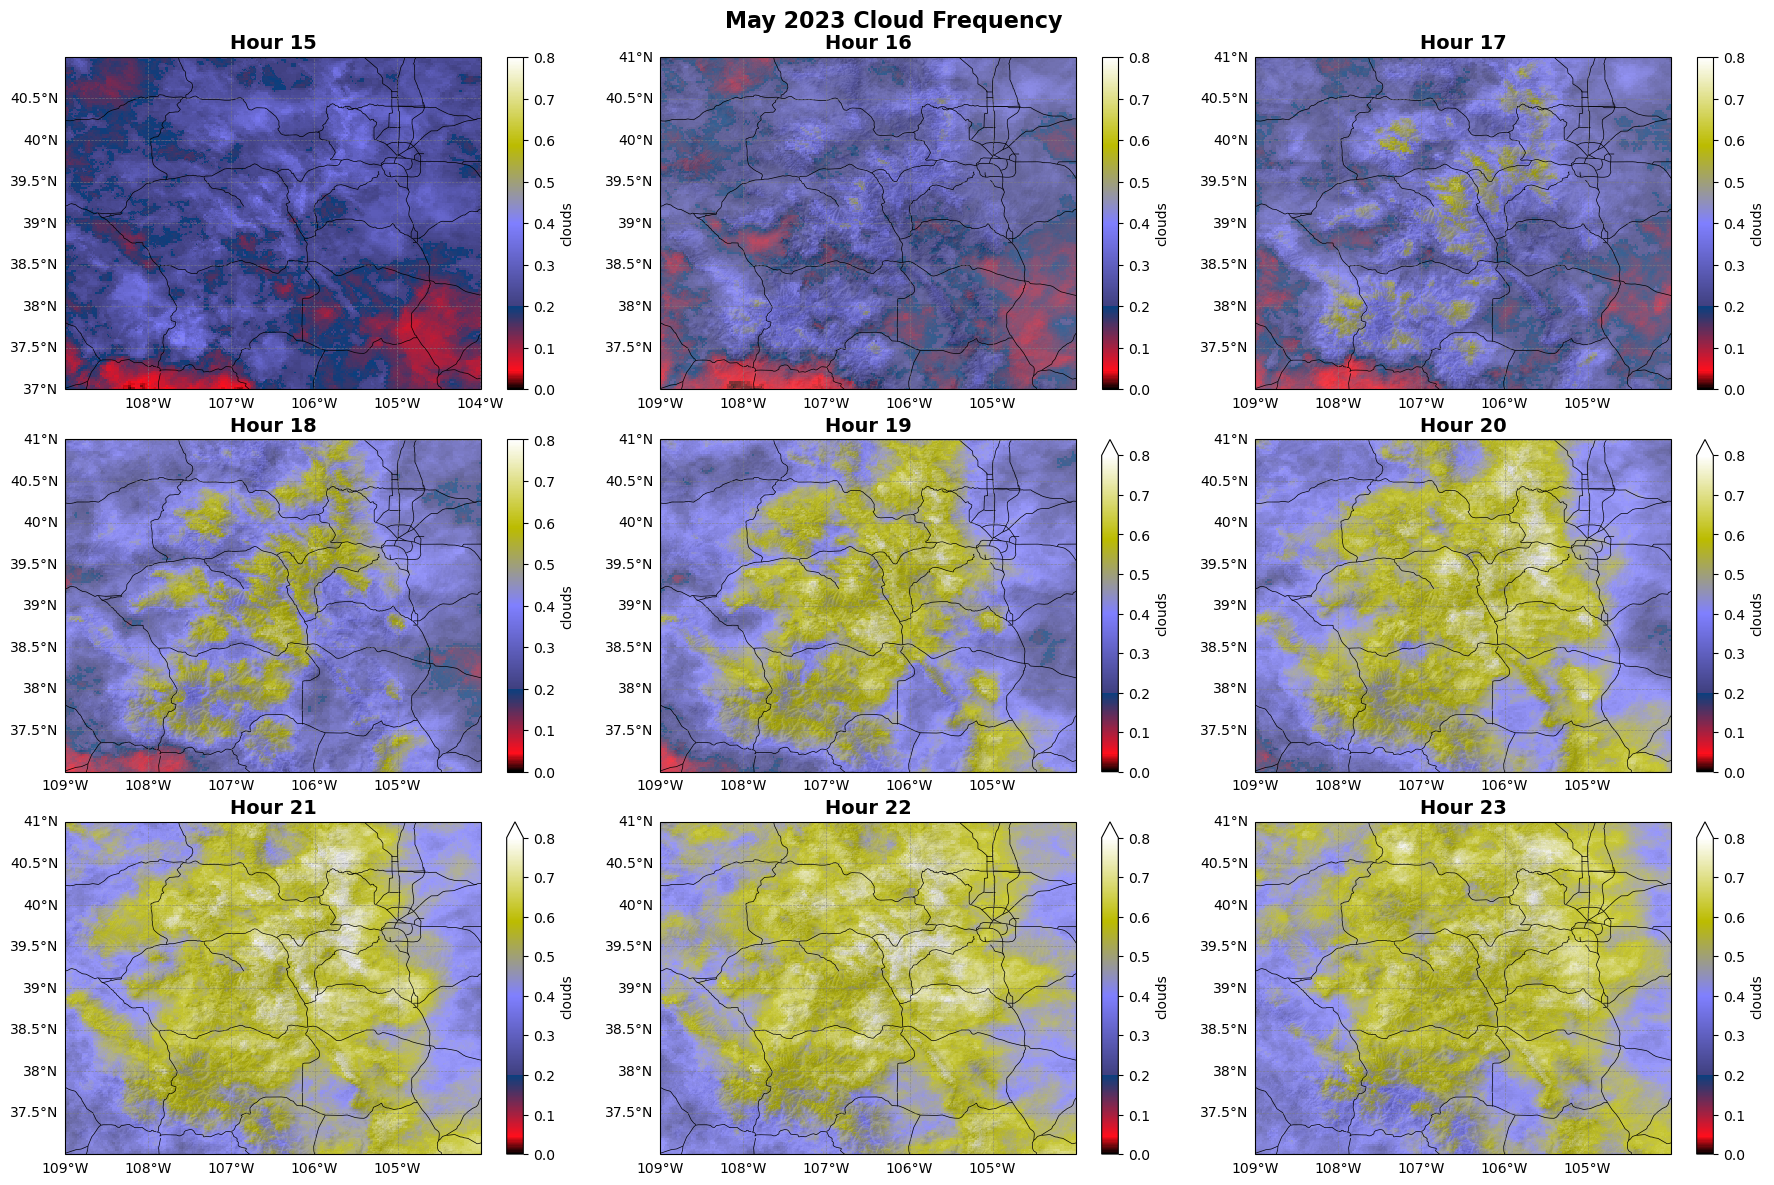

In [7]:
# Create the figure and subplots with Cartopy projection
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Define the colormap and normalization for consistent scaling
cmap = 'gist_stern'
vmin, vmax = 0, 0.8
month = 'May 2023'
month_name = '202305'
ds = may23_cloud_ds

# Plot January Morning Cloud Frequency
im = ds['clouds'].sel(local_hour=15).plot.imshow(ax=axes[0, 0], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
plot_features(axes[0, 0], 'white')
axes[0, 0].set_title(f'Hour 15', fontweight='bold', fontsize=14)

# Plot January Afternoon Cloud Frequency
ds['clouds'].sel(local_hour=18).plot.imshow(ax=axes[1, 0], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[1, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 0], 'white')
axes[1, 0].set_title(f'Hour 18', fontweight='bold', fontsize=14)

# Plot May Morning Cloud Frequency
ds['clouds'].sel(local_hour=16).plot.imshow(ax=axes[0, 1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[0, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 1], 'white')
axes[0, 1].set_title(f'Hour 16', fontweight='bold', fontsize=14)

# Plot May Afternoon Cloud Frequency
ds['clouds'].sel(local_hour=19).plot.imshow(ax=axes[1, 1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[1, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 1], 'white')
axes[1, 1].set_title(f'Hour 19', fontweight='bold', fontsize=14)

# Plot July Morning Cloud Frequency
ds['clouds'].sel(local_hour=17).plot.imshow(ax=axes[0, 2], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[0, 2].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 2], 'white')
axes[0, 2].set_title(f'Hour 17', fontweight='bold', fontsize=14)

# Plot July Afternoon Cloud Frequency
ds['clouds'].sel(local_hour=20).plot.imshow(ax=axes[1, 2], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[1, 2].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 2], 'white')
axes[1, 2].set_title(f'Hour 20', fontweight='bold', fontsize=14)

ds['clouds'].sel(local_hour=21).plot.imshow(ax=axes[2, 0], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[2, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[2, 0], 'white')
axes[2, 0].set_title(f'Hour 21', fontweight='bold', fontsize=14)

ds['clouds'].sel(local_hour=22).plot.imshow(ax=axes[2, 1], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[2, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[2, 1], 'white')
axes[2, 1].set_title(f'Hour 22', fontweight='bold', fontsize=14)

ds['clouds'].sel(local_hour=23).plot.imshow(ax=axes[2, 2], cmap=cmap, add_colorbar=True, vmin=vmin, vmax=vmax)
axes[2, 2].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[2, 2], 'white')
axes[2, 2].set_title(f'Hour 23', fontweight='bold', fontsize=14)

plt.suptitle(f'{month} Cloud Frequency', fontweight='bold', fontsize=16)

# Adjust layout for better spacing
plt.tight_layout()
plt.savefig(f'./plots/colorado_cloud_hourly_cycles_{month_name}.png', dpi=300)

#### April and May cloud frequencies

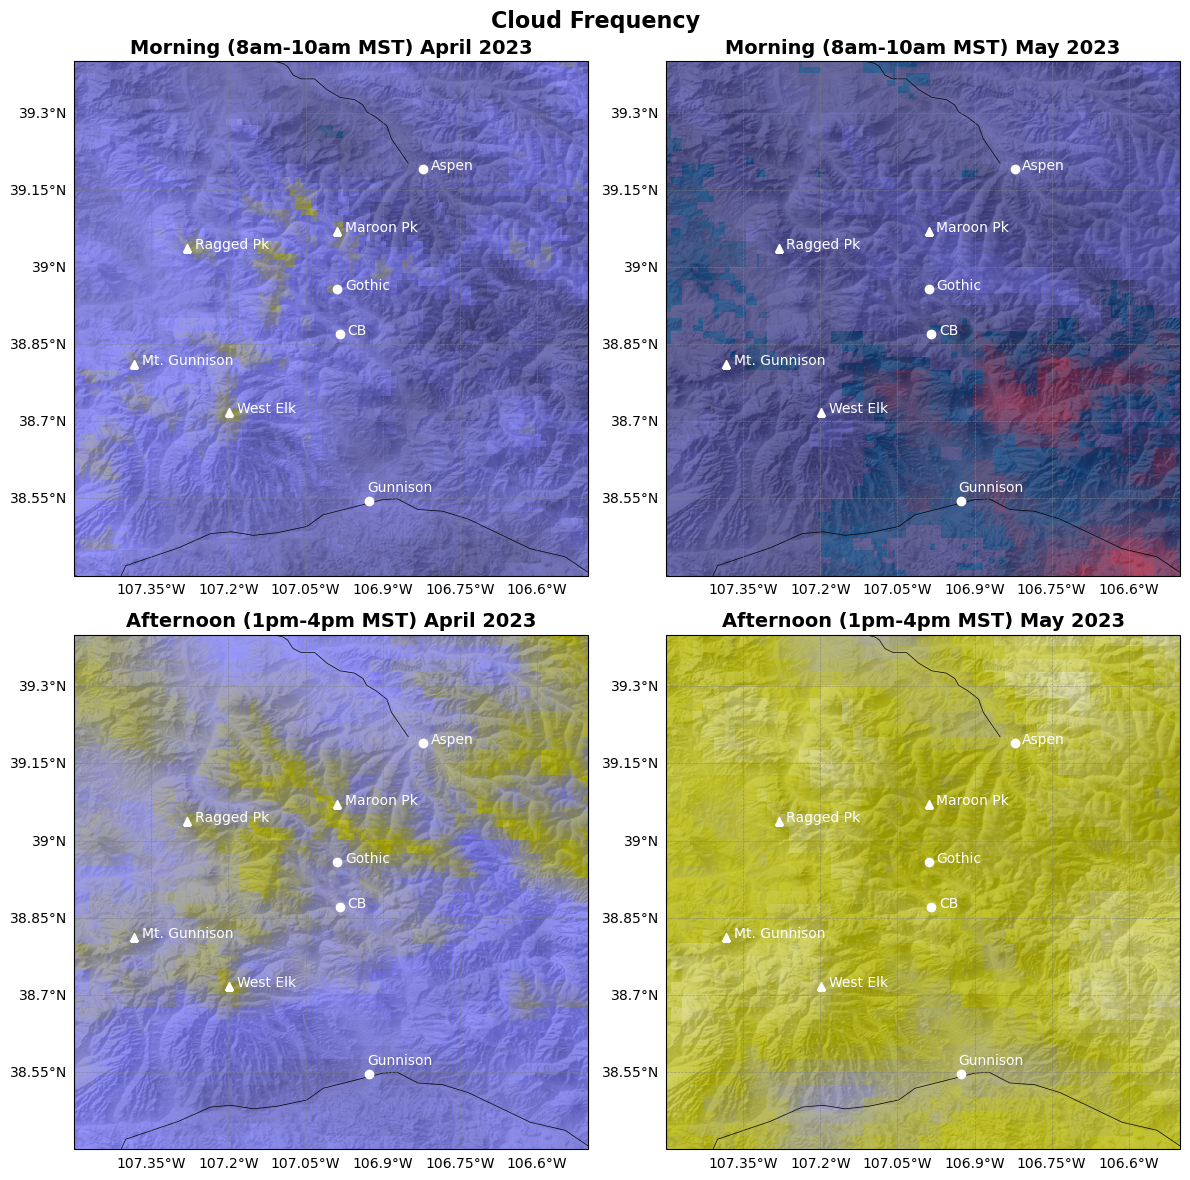

In [13]:
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 12))

# Define the colormap and normalization for consistent scaling
cmap = 'gist_stern'
vmin, vmax = 0, 80

# Plot April Morning Cloud Frequency
im = april23_morning_cloud_freq.plot.imshow(ax=axes[0, 0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[0, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 0], 'white')
axes[0, 0].set_title('Morning (8am-10am MST) April 2023', fontweight='bold', fontsize=14)

# Plot April Afternoon Cloud Frequency
april23_afternoon_cloud_freq.plot.imshow(ax=axes[1, 0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[1, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 0], 'white')
axes[1, 0].set_title('Afternoon (1pm-4pm MST) April 2023', fontweight='bold', fontsize=14)

# Plot May Morning Cloud Frequency
may23_morning_cloud_freq.plot.imshow(ax=axes[0, 1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[0, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 1], 'white')
axes[0, 1].set_title('Morning (8am-10am MST) May 2023', fontweight='bold', fontsize=14)

# Plot May Afternoon Cloud Frequency
may23_afternoon_cloud_freq.plot.imshow(ax=axes[1, 1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[1, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 1], 'white')
axes[1, 1].set_title('Afternoon (1pm-4pm MST) May 2023', fontweight='bold', fontsize=14)

plt.suptitle('Cloud Frequency', fontweight='bold', fontsize=16)

plt.tight_layout();

#### January vs February Cloud Frequencies

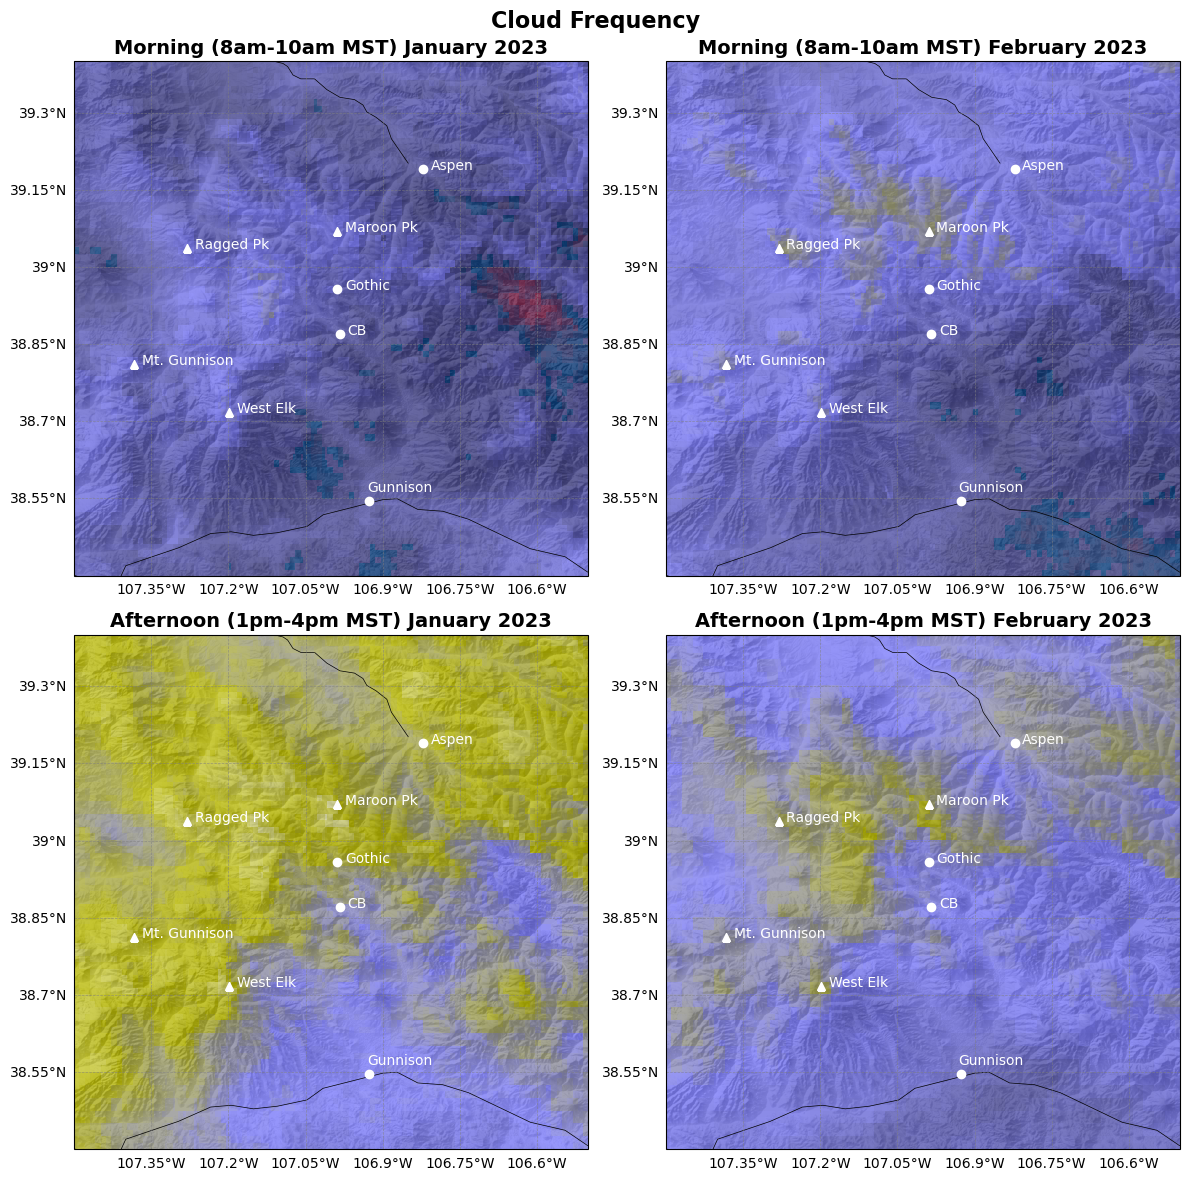

In [15]:
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 12))

# Define the colormap and normalization for consistent scaling
cmap = 'gist_stern'
vmin, vmax = 0, 80

# Plot January Morning Cloud Frequency
im = january_morning_cloud_freq.plot.imshow(ax=axes[0, 0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[0, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 0], 'white')
axes[0, 0].set_title('Morning (8am-10am MST) January 2023', fontweight='bold', fontsize=14)

# Plot January Afternoon Cloud Frequency
january_afternoon_cloud_freq.plot.imshow(ax=axes[1, 0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[1, 0].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 0], 'white')
axes[1, 0].set_title('Afternoon (1pm-4pm MST) January 2023', fontweight='bold', fontsize=14)

# Plot February Morning Cloud Frequency
february_morning_cloud_freq.plot.imshow(ax=axes[0, 1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[0, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[0, 1], 'white')
axes[0, 1].set_title('Morning (8am-10am MST) February 2023', fontweight='bold', fontsize=14)

# Plot February Afternoon Cloud Frequency
february_afternoon_cloud_freq.plot.imshow(ax=axes[1, 1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axes[1, 1].imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(axes[1, 1], 'white')
axes[1, 1].set_title('Afternoon (1pm-4pm MST) February 2023', fontweight='bold', fontsize=14)

plt.suptitle('Cloud Frequency', fontweight='bold', fontsize=16)

plt.tight_layout();

## Compare cloud frequency for different months at the same time of day

In [8]:
april_may_dif_afternoon_cloud_freq = april23_afternoon_cloud_freq - may23_afternoon_cloud_freq
april_may_dif_morning_cloud_freq = april23_morning_cloud_freq - may23_morning_cloud_freq

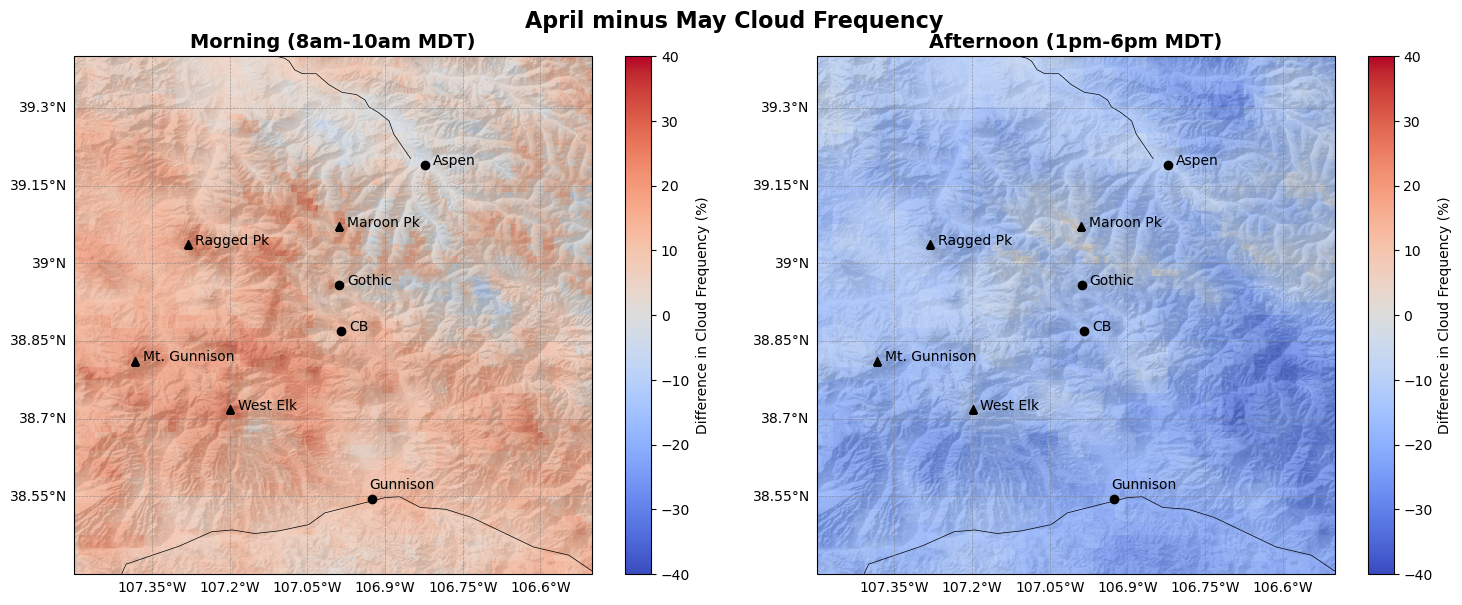

In [9]:
# Create the figure and subplots with Cartopy projection
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the morning frequency difference on the left subplot
april_may_dif_morning_cloud_freq.plot.imshow(ax=ax1, cmap='coolwarm', cbar_kwargs={'label': 'Difference in Cloud Frequency (%)'}, vmin=-40, vmax=40)
ax1.imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(ax1, 'black')
ax1.set_title('Morning (8am-10am MDT)', fontweight='bold', fontsize=14)

# Plot the afternoon frequency difference on the right subplot
april_may_dif_afternoon_cloud_freq.plot.imshow(ax=ax2, cmap='coolwarm', cbar_kwargs={'label': 'Difference in Cloud Frequency (%)'}, vmin=-40, vmax=40)
ax2.imshow(shaded, extent=extent, transform=ccrs.PlateCarree(), origin="upper", alpha=0.2)
plot_features(ax2, 'black')
ax2.set_title('Afternoon (1pm-6pm MDT)', fontweight='bold', fontsize=14)

plt.suptitle('April minus May Cloud Frequency', fontweight='bold', fontsize=16)

# Adjust layout for better spacing
plt.tight_layout()
